# 1. Installation, imports et loadings

In [42]:
import os
import glob
import json
from pathlib import Path

!pip install duckdb --quiet
!pip install numpy --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet
!pip install jinja2 --quiet
!pip install spicy --quiet


import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy.stats import pearsonr

import matplotlib.dates as mdates
!pip install plotly --quiet
!pip install --upgrade nbformat
import plotly.express as px
                                
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

                               
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f" {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")

                                          
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")

                                            
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print(" Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB")

 137 fichiers parquet trouvés (414.49 Go).
 Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB


# 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.
## 2.1. Broken ID and no source 

In [43]:
con.execute(r"""
    CREATE OR REPLACE VIEW gkg_clean AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

                    
bilan_nettoyage = con.execute("""
    SELECT 
        '1. GKG Brut' AS Etape, COUNT(*) AS Lignes_Totales 
    FROM gkg
    UNION ALL
    SELECT 
        '2. GKG Clean', COUNT(*) 
    FROM gkg_clean
""").df()

bilan_nettoyage['Lignes_Supprimees'] = bilan_nettoyage['Lignes_Totales'].iloc[0] - bilan_nettoyage['Lignes_Totales']
display(bilan_nettoyage.style.format({'Lignes_Totales': '{:,}', 'Lignes_Supprimees': '{:,}'}).hide(axis="index"))

Etape,Lignes_Totales,Lignes_Supprimees
1. GKG Brut,"1,580,905,613",0
2. GKG Clean,"1,580,880,862","24,751"


## 2.2 No theme-less

In [44]:
con.execute(r"""
    CREATE OR REPLACE VIEW gkg_themes AS
    
    SELECT *
    FROM gkg_clean
    WHERE EnhancedThemes IS NOT NULL 
      AND EnhancedThemes != ''
""")

# Bilan rapide de la création
bilan_themes = con.execute("""
    SELECT 
        '1. GKG Clean' AS Etape, COUNT(*) AS Lignes 
    FROM gkg_clean
    UNION ALL
    SELECT 
        '2. GKG Themes (Filtre appliqué)', COUNT(*) 
    FROM gkg_themes
""").df()

bilan_themes['Supprimées'] = bilan_themes['Lignes'].iloc[0] - bilan_themes['Lignes']
display(bilan_themes.style.format({'Lignes': '{:,}', 'Supprimées': '{:,}'}).hide(axis="index"))
print("Vue 'gkg_themes' créée avec succès.")

Etape,Lignes,Supprimées
1. GKG Clean,"1,580,880,862",0
2. GKG Themes (Filtre appliqué),"1,434,361,216","146,519,646"


Vue 'gkg_themes' créée avec succès.


## 2.3 Words outliers

In [47]:
MIN_WORDS = 15     # Exclut les brèves, les flux RSS et les erreurs (ex: 50 mots)
MAX_WORDS = 6500   # Exclut les rapports géants et les pages web entières mal découpées (ex: 4000 mots)

query_words = f"""
    CREATE OR REPLACE VIEW gkg_words AS
    
    SELECT *
    FROM gkg_themes
    WHERE WordCount BETWEEN {MIN_WORDS} AND {MAX_WORDS}
"""
con.execute(query_words)

bilan_words = con.execute(f"""
    SELECT 
        '1. GKG Themes' AS Etape, COUNT(*) AS Lignes 
    FROM gkg_themes
    UNION ALL
    SELECT 
        '2. GKG Words ({MIN_WORDS} à {MAX_WORDS} mots)', COUNT(*) 
    FROM gkg_words
""").df()

bilan_words['Supprimées'] = bilan_words['Lignes'].iloc[0] - bilan_words['Lignes']
display(bilan_words.style.format({'Lignes': '{:,}', 'Supprimées': '{:,}'}).hide(axis="index"))

Etape,Lignes,Supprimées
1. GKG Themes,"1,434,361,216",0
2. GKG Words (15 à 6500 mots),"1,431,705,950","2,655,266"


## 2.4 Amount of articles per source

In [48]:
MIN_ARTICLES_PER_SOURCE = 30

query_sources_view = f"""
    CREATE OR REPLACE VIEW gkg_sources AS
    
    WITH ValidSources AS (
        -- 1. On identifie les sources qui atteignent le seuil
        SELECT SourceCommonName_ID
        FROM gkg_words
        WHERE SourceCommonName_ID IS NOT NULL
        GROUP BY SourceCommonName_ID
        HAVING COUNT(*) >= {MIN_ARTICLES_PER_SOURCE}
    )
    -- 2. On filtre la base complète en ne gardant que ces sources
    SELECT w.*
    FROM gkg_words w
    INNER JOIN ValidSources v 
      ON w.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_sources_view)

# Bilan du filtrage
bilan_sources = con.execute(f"""
    WITH stats_words AS (
        SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_words
    ),
    stats_sources AS (
        SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_sources
    )
    SELECT 
        '1. GKG Words' AS Etape, 
        w.lignes AS "Nombre d'articles", 
        w.sources AS "Sources distinctes"
    FROM stats_words w
    UNION ALL
    SELECT 
        '2. GKG Sources (>= {MIN_ARTICLES_PER_SOURCE} articles)', 
        s.lignes, 
        s.sources
    FROM stats_sources s
""").df()

# Calcul des suppressions
articles_suppr = bilan_sources["Nombre d'articles"].iloc[0] - bilan_sources["Nombre d'articles"].iloc[1]
sources_suppr = bilan_sources["Sources distinctes"].iloc[0] - bilan_sources["Sources distinctes"].iloc[1]

print(f"✅ Vue créée. Bilan du nettoyage :")
print(f"- Articles supprimés : {articles_suppr:,}")
print(f"- Sources fantômes/micro-éditeurs éliminés : {sources_suppr:,}")

display(bilan_sources.style.format({"Nombre d'articles": '{:,}', "Sources distinctes": '{:,}'}).hide(axis="index"))

✅ Vue créée. Bilan du nettoyage :
- Articles supprimés : 856,380
- Sources fantômes/micro-éditeurs éliminés : 212,825


Etape,Nombre d'articles,Sources distinctes
1. GKG Words,"1,431,705,950","284,724"
2. GKG Sources (>= 30 articles),"1,430,849,570","71,899"


## 2.5 Years of activity per source

In [49]:
MIN_ACTIVE_YEARS = 2

query_year_view = f"""
    CREATE OR REPLACE VIEW gkg_year AS
    
    WITH ValidSources AS (
        -- On identifie les sources qui ont publié sur au moins X années distinctes
        SELECT SourceCommonName_ID
        FROM gkg_sources
        GROUP BY SourceCommonName_ID
        HAVING COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) >= {MIN_ACTIVE_YEARS}
    )
    -- On filtre en faisant une jointure interne
    SELECT s.*
    FROM gkg_sources s
    INNER JOIN ValidSources v 
      ON s.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_year_view)

# Bilan du filtrage
bilan_year = con.execute(f"""
    WITH stats_sources AS (
        SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_sources
    ),
    stats_year AS (
        SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_year
    )
    SELECT 
        '1. GKG Sources' AS Etape, 
        s.lignes AS "Nombre d'articles", 
        s.sources AS "Sources distinctes"
    FROM stats_sources s
    UNION ALL
    SELECT 
        '2. GKG Year (>= {MIN_ACTIVE_YEARS} ans)', 
        y.lignes, 
        y.sources
    FROM stats_year y
""").df()

# Calcul du nettoyage
articles_suppr = bilan_year["Nombre d'articles"].iloc[0] - bilan_year["Nombre d'articles"].iloc[1]
sources_suppr = bilan_year["Sources distinctes"].iloc[0] - bilan_year["Sources distinctes"].iloc[1]

print(f"✅ Vue 'gkg_year' créée. Bilan de l'écrémage éditorial :")
print(f"- Articles retirés : {articles_suppr:,}")
print(f"- Sources éphémères éliminées : {sources_suppr:,}")

display(bilan_year.style.format({"Nombre d'articles": '{:,}', "Sources distinctes": '{:,}'}).hide(axis="index"))

✅ Vue 'gkg_year' créée. Bilan de l'écrémage éditorial :
- Articles retirés : 3,342,958
- Sources éphémères éliminées : 4,208


Etape,Nombre d'articles,Sources distinctes
1. GKG Sources,"1,430,849,570","71,899"
2. GKG Year (>= 2 ans),"1,427,506,612","67,691"


## 2.6 Themes per source

In [50]:
MIN_THEMES = 2

query_final_view = f"""
    CREATE OR REPLACE VIEW gkg_final AS
    
    SELECT *
    FROM gkg_year
    WHERE CASE 
            WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 0 
            ELSE ARRAY_LENGTH(string_split(EnhancedThemes, ';')) 
          END >= {MIN_THEMES}
"""

con.execute(query_final_view)

## 2.7 1% of the database
We will only work with 1% of the database.

In [51]:
gkg_final_1pc = con.execute("""
    SELECT *
    FROM gkg_final
    WHERE hash(GKGRECORDID) % 100 = 0
    
""").df()

# 3. Impact of the main sources

We want to make sure that the top sources don't bias the results in terms of themes frequently mentioned, theme variety and tone.

In [53]:
n = 3 # top n sources

con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_sample AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_sample AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    OFFSET ?
""",[n] )

In [54]:
top_n_sources_sample = con.execute("SELECT * FROM top_n_sources_sample").df()

display(top_n_sources_sample.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Source_ID,Articles
iheart.com,82787,"221,403"
yahoo.com,81,"99,037"
zazoom.it,36148,"95,418"


## 3.1 Impact on the themes mentioned

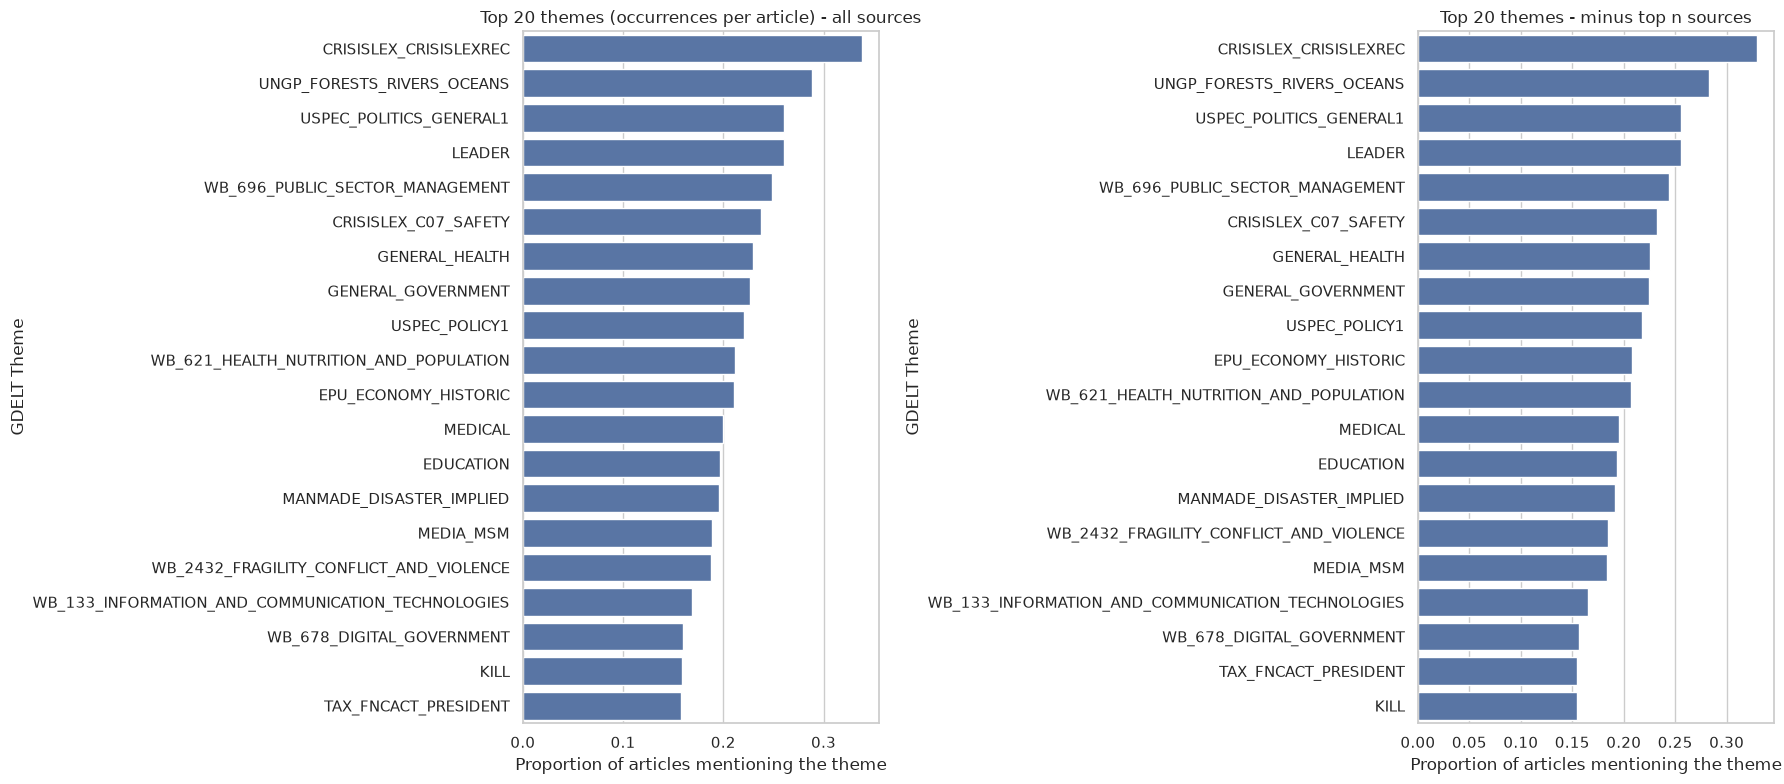

In [55]:
top_themes = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_minus_top_n = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc g
            JOIN minus_top_n_sources_sample m
                ON g.SourceCommonName_ID = m.Source_ID
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=top_themes, x="proportion", y="theme", ax=axes[0])
axes[0].set_title('Top 20 themes (occurrences per article) - all sources')
axes[0].set_xlabel('Proportion of articles mentioning the theme')
axes[0].set_ylabel('GDELT Theme')
 

sns.barplot(data=top_themes_minus_top_n, x="proportion", y="theme", ax=axes[1])
axes[1].set_title('Top 20 themes - minus top n sources')
axes[1].set_xlabel('Proportion of articles mentioning the theme')
axes[1].set_ylabel('GDELT Theme')

plt.tight_layout()
plt.show()

The 2 charts are extremely similar, which means that the top sources don't bias the results.

## 3.2 Impact on the variety of themes

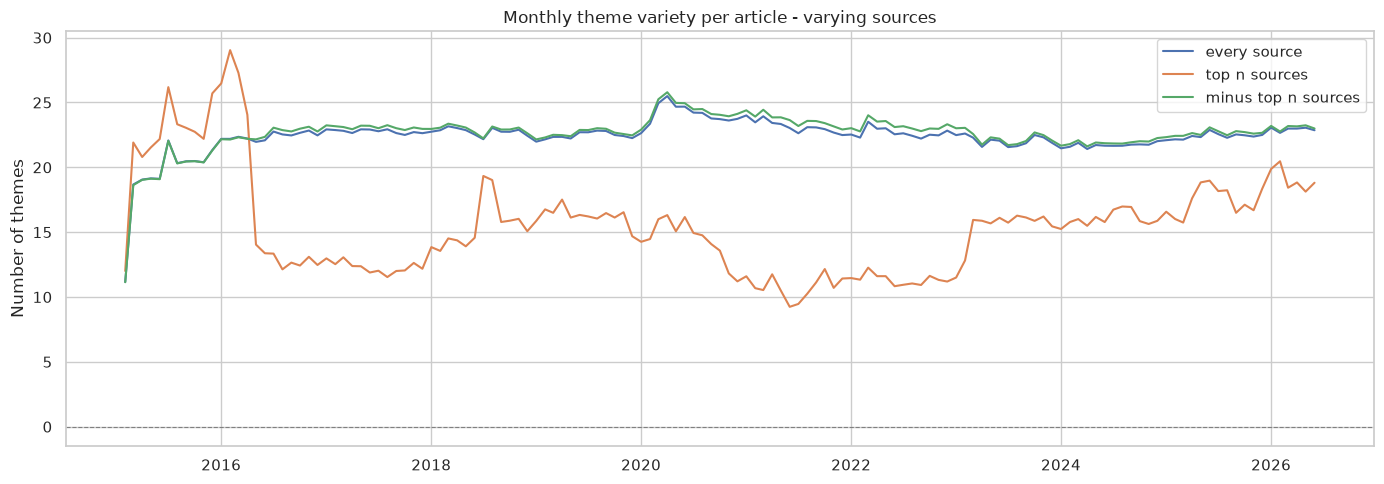

In [56]:
theme_variety_per_article = con.execute("""
    WITH article_themes AS (
        SELECT
            DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
            COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
        FROM (
            SELECT
                DATE,
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
        GROUP BY month, GKGRECORDID
    )

    SELECT
        month,
        AVG(nb_themes) AS avg_themes_per_article
    FROM article_themes
    GROUP BY month
    ORDER BY month;
""").df()

theme_variety_per_article_top_n = con.execute("""
    WITH article_themes AS (
        SELECT
            DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
            COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
        FROM (
            SELECT
                DATE,
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc g
            JOIN top_n_sources_sample t
                ON g.SourceCommonName_ID = t.Source_ID
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
        GROUP BY month, GKGRECORDID
    )

    SELECT
        month,
        AVG(nb_themes) AS avg_themes_per_article
    FROM article_themes
    GROUP BY month
    ORDER BY month;
""").df()

theme_variety_per_article_minus_top_n = con.execute("""
    WITH article_themes AS (
        SELECT
            DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
            COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
        FROM (
            SELECT
                DATE,
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc g
            JOIN minus_top_n_sources_sample m
                ON g.SourceCommonName_ID = m.Source_ID
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
        GROUP BY month, GKGRECORDID
    )

    SELECT
        month,
        AVG(nb_themes) AS avg_themes_per_article
    FROM article_themes
    GROUP BY month
    ORDER BY month;
""").df()


fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(theme_variety_per_article["month"], theme_variety_per_article["avg_themes_per_article"], label="every source")
ax.plot(theme_variety_per_article_top_n["month"], theme_variety_per_article_top_n["avg_themes_per_article"], label="top n sources")
ax.plot(theme_variety_per_article_minus_top_n["month"], theme_variety_per_article_minus_top_n["avg_themes_per_article"], label="minus top n sources")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Monthly theme variety per article - varying sources")
ax.set_ylabel("Number of themes")
ax.legend()
plt.tight_layout()
plt.show()

Since the "all sources" and "top n sources" curves are almost superimposed, the main sources don't bias the results.

Let's test the correlation between the "all sources" and 'top n sources" curves.

In [57]:
df = theme_variety_per_article.merge(
    theme_variety_per_article_top_n,
    on="month",
    suffixes=("_all", "_top")
)
df.head()

r = df["avg_themes_per_article_all"].corr(df["avg_themes_per_article_top"])

print(f"Corrélation de Pearson : {r:.3f}")

r, p = pearsonr(df["avg_themes_per_article_all"], df["avg_themes_per_article_top"])

print(f"r = {r:.3f}")
print(f"p-value = {p:.4g}")

Corrélation de Pearson : -0.281
r = -0.281
p-value = 0.0008846


=> weak correlation

## 3.3 Impact on the tone

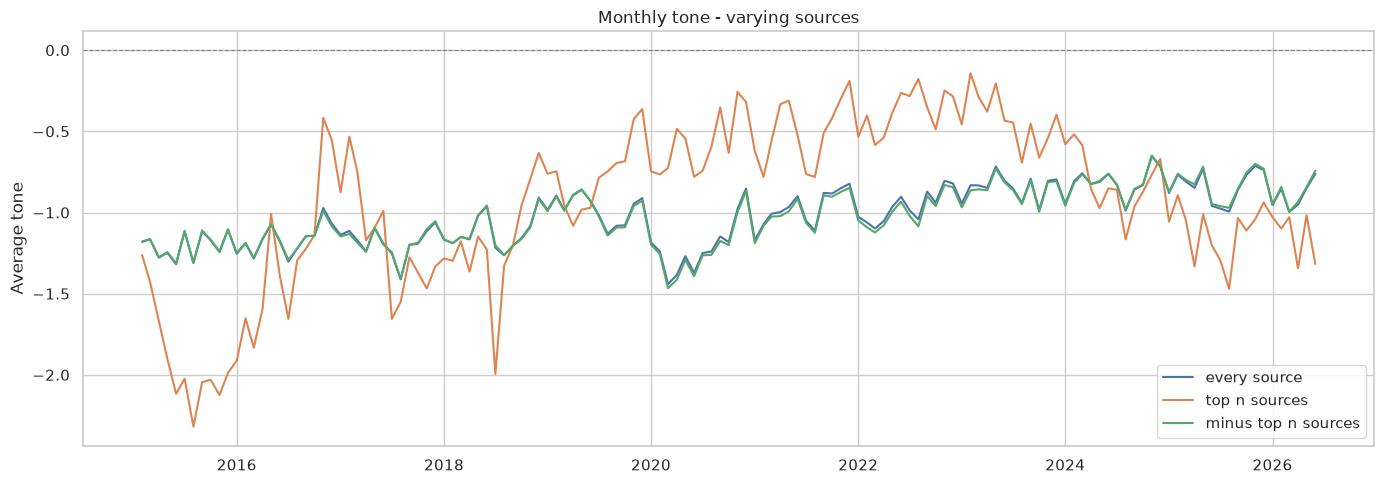

In [58]:
tone_monthly = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_final
    GROUP BY month
    ORDER BY month
""").df()

tone_monthly_top_n = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS nb
    FROM gkg_final g
    JOIN top_n_sources_sample t
        ON g.SourceCommonName_ID = t.Source_ID
    GROUP BY month
    ORDER BY month
""").df()

tone_monthly_minus_top_n = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS nb
    FROM gkg_final g
    JOIN minus_top_n_sources_sample t
        ON g.SourceCommonName_ID = t.Source_ID
    GROUP BY month
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tone_monthly["month"], tone_monthly["avg_tone"], label="every source")
ax.plot(tone_monthly_top_n["month"], tone_monthly_top_n["avg_tone"], label="top n sources")
ax.plot(tone_monthly_minus_top_n["month"], tone_monthly_minus_top_n["avg_tone"], label="minus top n sources")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Monthly tone - varying sources")
ax.set_ylabel("Average tone")
ax.legend()
plt.tight_layout()
plt.show()

Since the "all sources" and "top n sources" curves are almost superimposed, the main sources don't bias the results.

Let's test the correlation between the "all sources" and 'top n sources" curves.

In [59]:
df = tone_monthly.merge(
    tone_monthly_top_n,
    on="month",
    suffixes=("_all", "_top")
)
df.head()

r = df["avg_tone_all"].corr(df["avg_tone_top"])

print(f"Corrélation de Pearson : {r:.3f}")

r, p = pearsonr(df["avg_tone_all"], df["avg_tone_top"])

print(f"r = {r:.3f}")
print(f"p-value = {p:.4g}")

Corrélation de Pearson : 0.478
r = 0.478
p-value = 3.521e-09


=> no correlation

## Conclusion
The main sources don't bias the results. We don't have to clean the database in that sense.

# 4. Analysis of the temporal anomalities
## 4.1 Low peak 2020
Our two goals : 
+ Try to finde the cause of the anormality.
+ Make sure that the themes frequently mentioned, the theme variety and the tone aren't affected during this low peak.

zoom on the low peak :

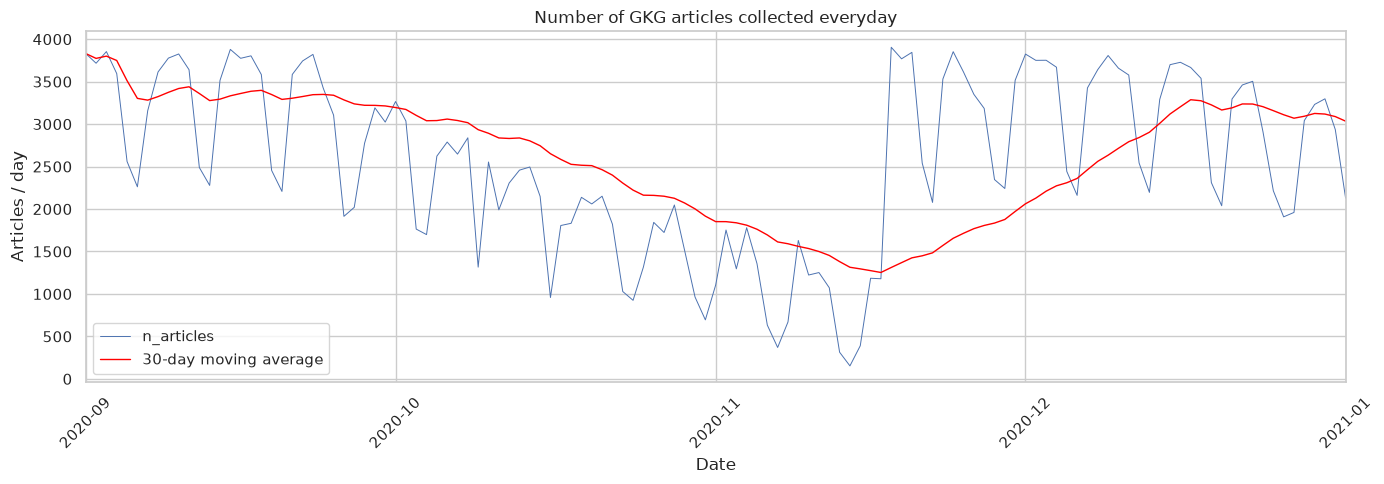

In [60]:
articles_per_day = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-01'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2021-01-01' 
    GROUP BY day
    ORDER BY day
""").df()

articles_per_day["day"] = pd.to_datetime(articles_per_day["day"])
articles_per_day = articles_per_day.set_index("day")

fig, ax = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1, color="red", label="30-day moving average"
)

ax.set_title("Number of GKG articles collected everyday")
ax.set_ylabel("Articles / day")
ax.set_xlabel("Date")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

finding the extrema to analyze the data there : 

In [61]:
articles_per_day_max_before = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202009%'
    GROUP BY day
    ORDER BY n_articles DESC
    LIMIT 1    
""").df()

articles_per_day_min = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
    WHERE DATE LIKE '202011%'
    GROUP BY day
    ORDER BY n_articles ASC
    LIMIT 1    
""").df()

articles_per_day_max_after = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202011%'
    GROUP BY day
    ORDER BY n_articles DESC
    LIMIT 1    
""").df()

display(articles_per_day_max_before.style.format({"n_articles": "{:,}"}).hide(axis="index"))
display(articles_per_day_min.style.format({"n_articles": "{:,}"}).hide(axis="index"))
display(articles_per_day_max_after.style.format({"n_articles": "{:,}"}).hide(axis="index"))

day,n_articles
2020-09-15 00:00:00,"3,880"


day,n_articles
2020-11-14 00:00:00,153


day,n_articles
2020-11-18 00:00:00,"3,905"


### 4.1.1 Most frequent themes

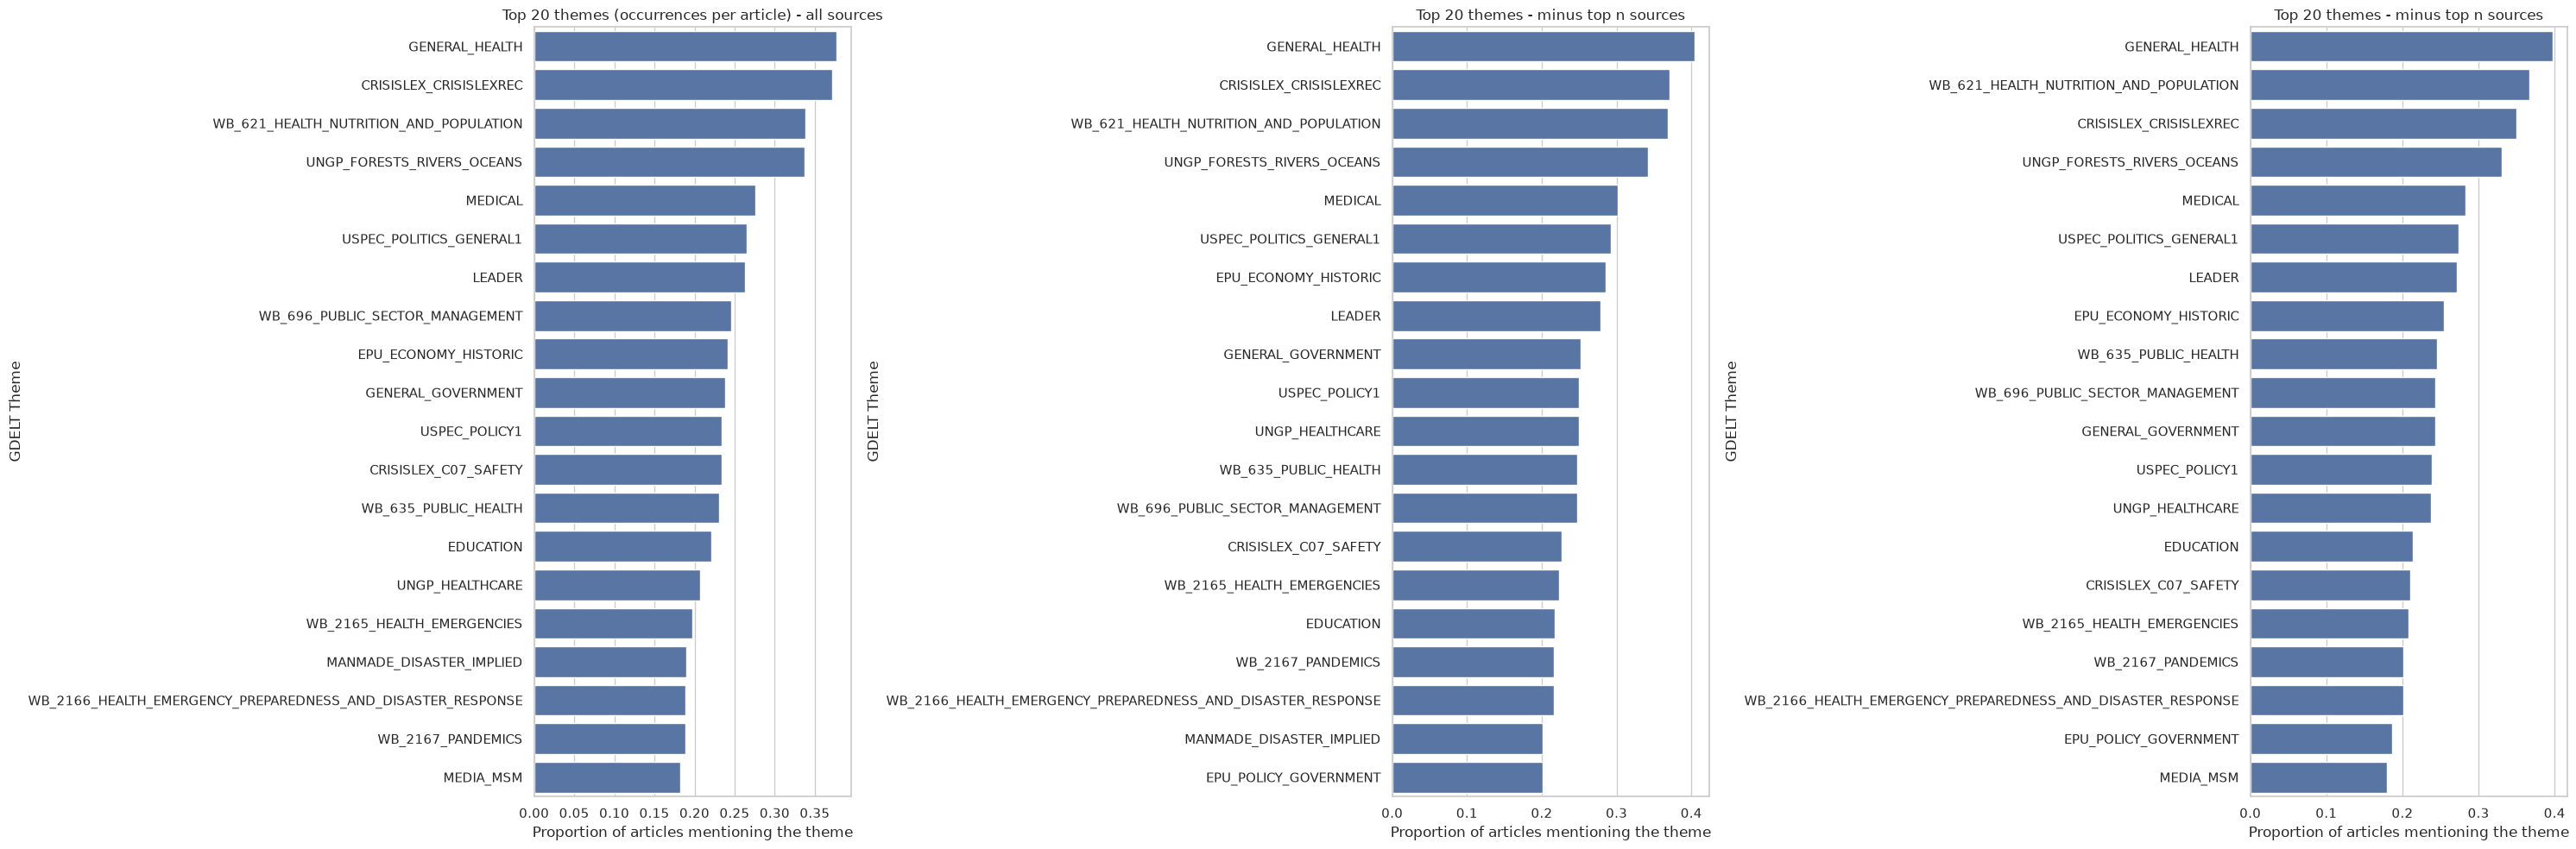

In [63]:
top_themes_2020_09_15 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'   
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15' 
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_2020_11_14 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15' 
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15' 
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_2020_11_18 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20' 
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20' 
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()


fig, axes = plt.subplots(1, 3, figsize=(30,10))

sns.barplot(data=top_themes_2020_09_15, x="proportion", y="theme", ax=axes[0])
axes[0].set_title('Top 20 themes (occurrences per article) - all sources')
axes[0].set_xlabel('Proportion of articles mentioning the theme')
axes[0].set_ylabel('GDELT Theme')
 

sns.barplot(data=top_themes_2020_11_14, x="proportion", y="theme", ax=axes[1])
axes[1].set_title('Top 20 themes - minus top n sources')
axes[1].set_xlabel('Proportion of articles mentioning the theme')
axes[1].set_ylabel('GDELT Theme')

sns.barplot(data=top_themes_2020_11_18, x="proportion", y="theme", ax=axes[2])
axes[2].set_title('Top 20 themes - minus top n sources')
axes[2].set_xlabel('Proportion of articles mentioning the theme')
axes[2].set_ylabel('GDELT Theme')

plt.tight_layout()
plt.show()

The most frequent themes are almost the same ones at the 3 extrema (18 shared themes out of 20), and the proportions are also pretty similar.

### 4.1.2 Theme variety per article

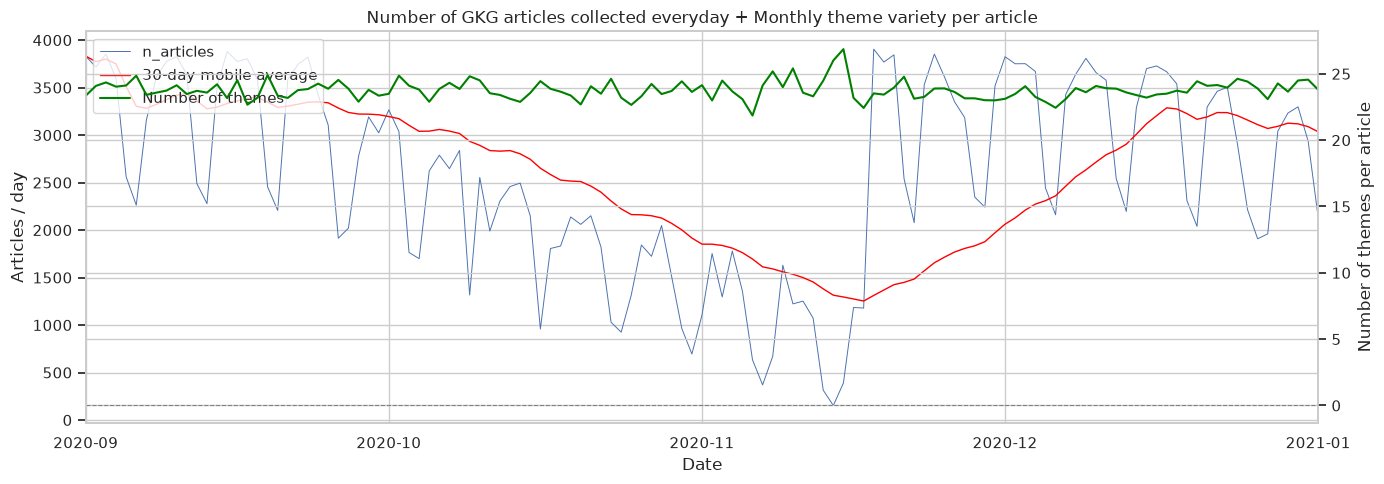

In [64]:
theme_variety_per_article_low_peak_2020 = con.execute("""
    WITH article_themes AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
    FROM (
        SELECT
            DATE,
            GKGRECORDID,
            UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_final_1pc
    )
    WHERE theme_raw IS NOT NULL
    AND theme_raw != ''
    GROUP BY day, GKGRECORDID
)

SELECT
    day,
    AVG(nb_themes) AS avg_themes_per_article
FROM article_themes
GROUP BY day
ORDER BY day;
""").df()


fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day mobile average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(theme_variety_per_article_low_peak_2020["day"], theme_variety_per_article_low_peak_2020["avg_themes_per_article"], color="green", label="Number of themes")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Number of themes per article")

ax1.set_title("Number of GKG articles collected everyday + Monthly theme variety per article")
ax1.set_xlim(pd.to_datetime('2020-09-01'), pd.to_datetime('2021-01-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The theme variety per article doesn't seem to be affected.

### 4.1.3 Tone

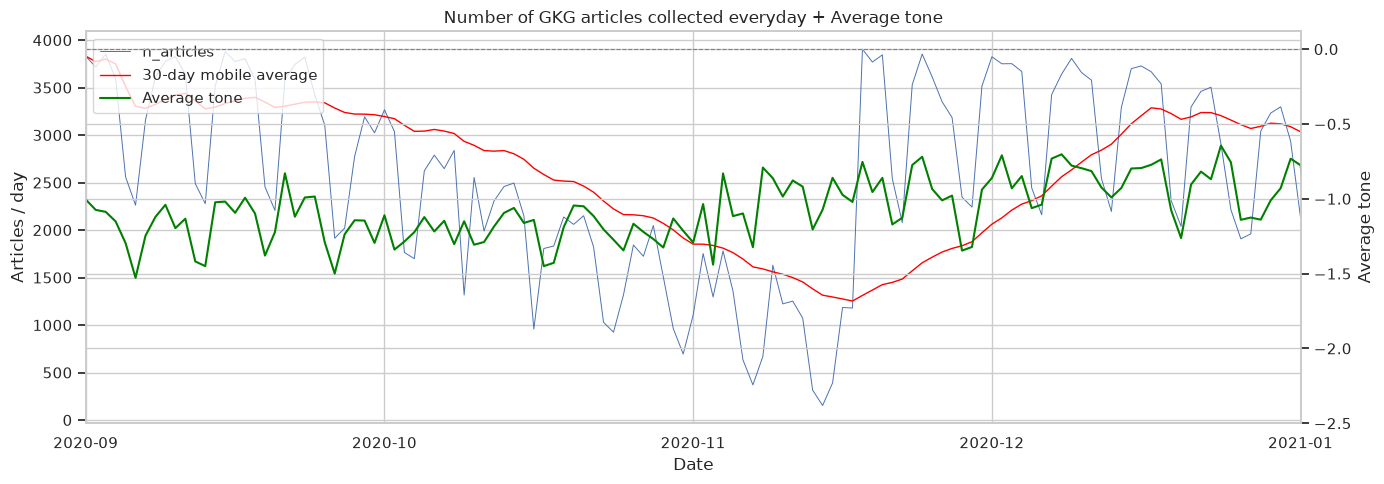

In [65]:
tone_low_peak_2020 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_final_1pc
    GROUP BY day
    ORDER BY day
""").df()

fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day mobile average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(tone_low_peak_2020["day"], tone_low_peak_2020["avg_tone"], color="green", label="Average tone")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Average tone")

ax1.set_title("Number of GKG articles collected everyday + Average tone")
ax1.set_xlim(pd.to_datetime('2020-09-01'), pd.to_datetime('2021-01-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The tone doesn't seem to be affected.

### 4.1.4 Main sources

In [ ]:
n = 20 # top n sources 

top_n_sources_2020_09_15 = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15' 
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT ?
""",[n] ).df()

top_n_sources_2020_11_14 = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15'      
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT ?
""",[n] ).df()

top_n_sources_2020_11_18 = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20'   
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT ?
""",[n] ).df()


display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2020-09-15</h4>
        {top_n_sources_2020_09_15.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-14</h4>
        {top_n_sources_2020_11_14.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-18</h4>
        {top_n_sources_2020_11_18.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Source_ID,Articles
iheart.com,82787,155
msn.com,427,132
zazoom.it,36148,125
tribunnews.com,26651,73
reuters.com,175,67
sina.com.cn,34473,62
yahoo.com,81,60
tin247.com,153611,54
haberler.com,6652,43
baomoi.com,28339,41


In [81]:
con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_2020_09_15 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15' 
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    OFFSET ?
""",[n] )

con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_2020_11_14 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15'      
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    OFFSET ?
""",[n] )

con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_2020_11_18 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20'   
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    OFFSET ?
""",[n] )

Since there are major differences in the main sources and the number of articles they have published in a day, we will conduct a more in depth analysys of the way they reacted to the low peak.

#### 4.1.4.1 Percentage of articles published by the top sources at each extrema
We want to see what percentage the top sources of 2020-09-15 (pre-peak top sources) accounts for on each extrema.

In [165]:
top_n_sources_2020_11_14_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_09_15
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_14
    ) AS i
    JOIN top_n_sources_2020_11_14 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_11_14_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
indiatimes.com,9
msn.com,9
regnum.ru,8
baomoi.com,8
reuters.com,7
zazoom.it,6
tribunnews.com,5
haberler.com,5
yahoo.com,5
eastmoney.com,5


In [169]:
top_n_sources_2020_11_18_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_09_15
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_18
    ) AS i
    JOIN top_n_sources_2020_11_18 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_11_18_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,196
zazoom.it,149
msn.com,98
reuters.com,98
sina.com.cn,81
tribunnews.com,66
prnewswire.com,52
finanznachrichten.de,48
haberler.com,39
tin247.com,37


In [171]:
nb_articles_per_day_2020_09_15 = con.execute("""
    WITH exploded AS (
        SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
            COUNT(*) AS nb_articles
        FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'   
        GROUP BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

nb_articles_per_day_2020_11_14 = con.execute("""
    WITH exploded AS (
        SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
            COUNT(*) AS nb_articles
        FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15'    
        GROUP BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

nb_articles_per_day_2020_11_18 = con.execute("""
    WITH exploded AS (
        SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
            COUNT(*) AS nb_articles
        FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20'    
        GROUP BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [172]:
values_nb_articles_total_2020_09_15 = [
    nb_articles_per_day_2020_09_15["avg_nb_articles"].iloc[0]
]

values_nb_articles_total_2020_11_14 = [
    nb_articles_per_day_2020_11_14["avg_nb_articles"].iloc[0]
]

values_nb_articles_total_2020_11_18 = [
    nb_articles_per_day_2020_11_18["avg_nb_articles"].iloc[0]
]

res_pc_articles_by_top_n_sources_2020_09_15 = round(100 * (top_n_sources_2020_09_15["Articles"].sum() / values_nb_articles_total_2020_09_15[0]), 2)
res_pc_articles_by_top_n_sources_2020_11_14 = round(100 * (top_n_sources_2020_11_14_max["Articles"].sum() / values_nb_articles_total_2020_11_14[0]), 2)
res_pc_articles_by_top_n_sources_2020_11_18 = round(100 * (top_n_sources_2020_11_14_max["Articles"].sum() / values_nb_articles_total_2020_11_18[0]), 2)

print ("percentage artcles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2020_09_15, "%\n")
print ("percentage artcles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2020_11_14, "%\n")
print ("percentage artcles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2020_11_18, "%\n")

percentage artcles published by the top n sources 2023-03-22 : 33.41 %

percentage artcles published by the top n sources 2023-03-22 : 26.6 %

percentage artcles published by the top n sources 2023-03-22 : 1.98 %



#### 4.1.4.2 Percentage variation between the extrema - number of articles collected

In [88]:
# all sources

avg_nb_articles_2020_09_15_all_sources = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_all_sources = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_all_sources = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [89]:
# top n sources 2020-09-15

avg_nb_articles_2020_09_15_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_09_15 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_top_n_sources_1 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_09_15 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_09_15 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [91]:
# minus top n sources 2020-09-15

avg_nb_articles_2020_09_15_minus_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_09_15 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_minus_top_n_sources_1 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_09_15 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_minus_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_09_15 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [92]:
# top n sources 2020-11-14

avg_nb_articles_2020_09_15_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_11_14 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_top_n_sources_2 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_11_14 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_11_14 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [93]:
# minus top n sources 2020-11-14

avg_nb_articles_2020_09_15_minus_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_11_14 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_minus_top_n_sources_2 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_11_14 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_minus_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_11_14 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [94]:
# top n sources 2020-11-18

avg_nb_articles_2020_09_15_top_n_sources_3 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_11_18 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_top_n_sources_3 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_11_18 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_top_n_sources_3 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2020_11_18 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [95]:
# minus top n sources 2020-11-18

avg_nb_articles_2020_09_15_minus_top_n_sources_3 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_11_18 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2020_11_14_minus_top_n_sources_3 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           COUNT(*) AS avg_nb_articles,
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_11_18 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY day
    ORDER BY day
""").df()

avg_nb_articles_2020_11_18_minus_top_n_sources_3 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2020_11_18 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [96]:
values_all_sources = [
    avg_nb_articles_2020_09_15_all_sources["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_all_sources["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_all_sources["avg_nb_articles"].iloc[0]
]

values_top_n_sources_1 = [
    avg_nb_articles_2020_09_15_top_n_sources_1["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_top_n_sources_1["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_top_n_sources_1["avg_nb_articles"].iloc[0]
]

values_minus_top_n_sources_1 = [
    avg_nb_articles_2020_09_15_minus_top_n_sources_1["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_minus_top_n_sources_1["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_minus_top_n_sources_1["avg_nb_articles"].iloc[0]
]

values_top_n_sources_2 = [
    avg_nb_articles_2020_09_15_top_n_sources_2["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_top_n_sources_2["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_top_n_sources_2["avg_nb_articles"].iloc[0]
]

values_minus_top_n_sources_2 = [
    avg_nb_articles_2020_09_15_minus_top_n_sources_2["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_minus_top_n_sources_2["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_minus_top_n_sources_2["avg_nb_articles"].iloc[0]
]

values_top_n_sources_3 = [
    avg_nb_articles_2020_09_15_top_n_sources_3["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_top_n_sources_3["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_top_n_sources_3["avg_nb_articles"].iloc[0]
]

values_minus_top_n_sources_3 = [
    avg_nb_articles_2020_09_15_minus_top_n_sources_3["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_14_minus_top_n_sources_3["avg_nb_articles"].iloc[0],
    avg_nb_articles_2020_11_18_minus_top_n_sources_3["avg_nb_articles"].iloc[0]
]


res1_values_all_sources = round(100 * (values_all_sources[1] / values_all_sources[0] - 1), 2)
res2_values_all_sources = round(100 * (values_all_sources[2] / values_all_sources[1] - 1), 2)

res1_values_top_n_sources_1 = round(100 * (values_top_n_sources_1[1] / values_top_n_sources_1[0] - 1), 2)
res2_values_top_n_sources_1 = round(100 * (values_top_n_sources_1[2] / values_top_n_sources_1[1] - 1), 2)

res1_values_minus_top_n_sources_1 = round(100 * (values_minus_top_n_sources_1[1] / values_minus_top_n_sources_1[0] - 1), 2)
res2_values_minus_top_n_sources_1 = round(100 * (values_minus_top_n_sources_1[2] / values_minus_top_n_sources_1[1] - 1), 2)

res1_values_top_n_sources_2 = round(100 * (values_top_n_sources_2[1] / values_top_n_sources_2[0] - 1), 2)
res2_values_top_n_sources_2 = round(100 * (values_top_n_sources_2[2] / values_top_n_sources_2[1] - 1), 2)

res1_values_minus_top_n_sources_2 = round(100 * (values_minus_top_n_sources_2[1] / values_minus_top_n_sources_2[0] - 1), 2)
res2_values_minus_top_n_sources_2 = round(100 * (values_minus_top_n_sources_2[2] / values_minus_top_n_sources_2[1] - 1), 2)

res1_values_top_n_sources_3 = round(100 * (values_top_n_sources_3[1] / values_top_n_sources_3[0] - 1), 2)
res2_values_top_n_sources_3 = round(100 * (values_top_n_sources_3[2] / values_top_n_sources_3[1] - 1), 2)

res1_values_minus_top_n_sources_3 = round(100 * (values_minus_top_n_sources_3[1] / values_minus_top_n_sources_3[0] - 1), 2)
res2_values_minus_top_n_sources_3 = round(100 * (values_minus_top_n_sources_3[2] / values_minus_top_n_sources_3[1] - 1), 2)


print ("percentage variation all sources - down :", res1_values_all_sources, "%")
print ("percentage variation all sources - up :", res2_values_all_sources, "%\n")

print ("percentage variation top n sources 2020-09-15 - down :", res1_values_top_n_sources_1, "%")
print ("percentage variation top n sources 2020-09-15 - up :", res2_values_top_n_sources_1, "%\n")

print ("percentage variation minus top n sources 2020-09-15 - down :", res1_values_minus_top_n_sources_1, "%")
print ("percentage variation minus top n sources 2020-09-15 - up :", res2_values_minus_top_n_sources_1, "%\n")

print ("percentage variation top n sources 2020-11-14 - down :", res1_values_top_n_sources_2, "%")
print ("percentage variation top n sources 2020-11-14 - up :", res2_values_top_n_sources_2, "%\n")

print ("percentage variation minus top n sources 2020-11-14 - down :", res1_values_minus_top_n_sources_2, "%")
print ("percentage variation minus top n sources 2020-11-14 - up :", res2_values_minus_top_n_sources_2, "%\n")

print ("percentage variation top n sources 2020-11-18 - down :", res1_values_top_n_sources_3, "%")
print ("percentage variation top n sources 2020-11-18 - up :", res2_values_top_n_sources_3, "%\n")

print ("percentage variation minus top n sources 2020-11-18 - down :", res1_values_minus_top_n_sources_3, "%")
print ("percentage variation minus top n sources 2020-11-18 - up :", res2_values_minus_top_n_sources_3, "%\n")

percentage variation all sources - down : -95.42 %
percentage variation all sources - up : 2096.27 %

percentage variation top n sources 2020-09-15 - down : -97.29 %
percentage variation top n sources 2020-09-15 - up : 3161.43 %

percentage variation minus top n sources 2020-09-15 - down : -95.97 %
percentage variation minus top n sources 2020-09-15 - up : 1992.64 %

percentage variation top n sources 2020-11-14 - down : -96.28 %
percentage variation top n sources 2020-11-14 - up : 2427.27 %

percentage variation minus top n sources 2020-11-14 - down : -75.97 %
percentage variation minus top n sources 2020-11-14 - up : 341.05 %

percentage variation top n sources 2020-11-18 - down : -96.83 %
percentage variation top n sources 2020-11-18 - up : 2912.99 %

percentage variation minus top n sources 2020-11-18 - down : -94.66 %
percentage variation minus top n sources 2020-11-18 - up : 2261.73 %



#### 4.1.4.3 Percentage variation between the extrema - theme variety

In [109]:
# all sources

avg_theme_variety_2020_09_15_all_sources = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_all_sources = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_all_sources = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [110]:
# top n sources 2020-09-15

avg_theme_variety_2020_09_15_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_09_15 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_09_15 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_09_15 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [132]:
# minus top n sources 2020-09-15

avg_theme_variety_2020_09_15_minus_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_09_15 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_minus_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_09_15 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_minus_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_09_15 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [93]:
# top n sources 2020-11-14

avg_theme_variety_2020_09_15_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_11_14 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_11_14 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_11_14 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [133]:
# minus top n sources 2020-11-14

avg_theme_variety_2020_09_15_minus_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_11_14 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_minus_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_11_14 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_minus_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_11_14 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [94]:
# top n sources 2020-11-18

avg_theme_variety_2020_09_15_top_n_sources_3 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_11_18 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_top_n_sources_3 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_11_18 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_top_n_sources_3 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2020_11_18 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [134]:
# minus top n sources 2020-11-18

avg_theme_variety_2020_09_15_minus_top_n_sources_3 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_11_18 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-09'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_14_minus_top_n_sources_3 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_11_18 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2020_11_18_minus_top_n_sources_3 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2020_11_18 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-24'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [136]:
values_all_sources = [
    avg_theme_variety_2020_09_15_all_sources["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_all_sources["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_all_sources["avg_nb_themes_per_article"].iloc[0]
]

values_top_n_sources_1 = [
    avg_theme_variety_2020_09_15_top_n_sources_1["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_top_n_sources_1["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_top_n_sources_1["avg_nb_themes_per_article"].iloc[0]
]

values_minus_top_n_sources_1 = [
    avg_theme_variety_2020_09_15_minus_top_n_sources_1["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_minus_top_n_sources_1["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_minus_top_n_sources_1["avg_nb_themes_per_article"].iloc[0]
]

values_top_n_sources_2 = [
    avg_theme_variety_2020_09_15_top_n_sources_2["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_top_n_sources_2["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_top_n_sources_2["avg_nb_themes_per_article"].iloc[0]
]

values_minus_top_n_sources_2 = [
    avg_theme_variety_2020_09_15_minus_top_n_sources_2["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_minus_top_n_sources_2["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_minus_top_n_sources_2["avg_nb_themes_per_article"].iloc[0]
]

values_top_n_sources_3 = [
    avg_theme_variety_2020_09_15_top_n_sources_3["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_top_n_sources_3["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_top_n_sources_3["avg_nb_themes_per_article"].iloc[0]
]

values_minus_top_n_sources_3 = [
    avg_theme_variety_2020_09_15_minus_top_n_sources_3["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_14_minus_top_n_sources_3["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2020_11_18_minus_top_n_sources_3["avg_nb_themes_per_article"].iloc[0]
]


res1_values_all_sources = round(100 * (values_all_sources[1] / values_all_sources[0] - 1), 2)
res2_values_all_sources = round(100 * (values_all_sources[2] / values_all_sources[1] - 1), 2)

res1_values_top_n_sources_1 = round(100 * (values_top_n_sources_1[1] / values_top_n_sources_1[0] - 1), 2)
res2_values_top_n_sources_1 = round(100 * (values_top_n_sources_1[2] / values_top_n_sources_1[1] - 1), 2)

res1_values_minus_top_n_sources_1 = round(100 * (values_minus_top_n_sources_1[1] / values_minus_top_n_sources_1[0] - 1), 2)
res2_values_minus_top_n_sources_1 = round(100 * (values_minus_top_n_sources_1[2] / values_minus_top_n_sources_1[1] - 1), 2)

res1_values_top_n_sources_2 = round(100 * (values_top_n_sources_2[1] / values_top_n_sources_2[0] - 1), 2)
res2_values_top_n_sources_2 = round(100 * (values_top_n_sources_2[2] / values_top_n_sources_2[1] - 1), 2)

res1_values_minus_top_n_sources_2 = round(100 * (values_minus_top_n_sources_2[1] / values_minus_top_n_sources_2[0] - 1), 2)
res2_values_minus_top_n_sources_2 = round(100 * (values_minus_top_n_sources_2[2] / values_minus_top_n_sources_2[1] - 1), 2)

res1_values_top_n_sources_3 = round(100 * (values_top_n_sources_3[1] / values_top_n_sources_3[0] - 1), 2)
res2_values_top_n_sources_3 = round(100 * (values_top_n_sources_3[2] / values_top_n_sources_3[1] - 1), 2)

res1_values_minus_top_n_sources_3 = round(100 * (values_minus_top_n_sources_3[1] / values_minus_top_n_sources_3[0] - 1), 2)
res2_values_minus_top_n_sources_3 = round(100 * (values_minus_top_n_sources_3[2] / values_minus_top_n_sources_3[1] - 1), 2)


print ("percentage variation all sources - down :", res1_values_all_sources, "%")
print ("percentage variation all sources - up :", res2_values_all_sources, "%\n")

print ("percentage variation top n sources 2020-09-15 - down :", res1_values_top_n_sources_1, "%")
print ("percentage variation top n sources 2020-09-15 - up :", res2_values_top_n_sources_1, "%\n")

print ("percentage variation minus top n sources 2020-09-15 - down :", res1_values_minus_top_n_sources_1, "%")
print ("percentage variation minus top n sources 2020-09-15 - up :", res2_values_minus_top_n_sources_1, "%\n")

print ("percentage variation top n sources 2020-11-14 - down :", res1_values_top_n_sources_2, "%")
print ("percentage variation top n sources 2020-11-14 - up :", res2_values_top_n_sources_2, "%\n")

print ("percentage variation minus top n sources 2020-11-14 - down :", res1_values_minus_top_n_sources_2, "%")
print ("percentage variation minus top n sources 2020-11-14 - up :", res2_values_minus_top_n_sources_2, "%\n")

print ("percentage variation top n sources 2020-11-18 - down :", res1_values_top_n_sources_3, "%")
print ("percentage variation top n sources 2020-11-18 - up :", res2_values_top_n_sources_3, "%\n")

print ("percentage variation minus top n sources 2020-11-18 - down :", res1_values_minus_top_n_sources_3, "%")
print ("percentage variation minus top n sources 2020-11-18 - up :", res2_values_minus_top_n_sources_3, "%\n")

percentage variation all sources - down : 9.65 %
percentage variation all sources - up : -8.83 %

percentage variation top n sources 2020-09-15 - down : 5.07 %
percentage variation top n sources 2020-09-15 - up : -5.86 %

percentage variation minus top n sources 2020-09-15 - down : 7.13 %
percentage variation minus top n sources 2020-09-15 - up : -4.88 %

percentage variation top n sources 2020-11-14 - down : 14.7 %
percentage variation top n sources 2020-11-14 - up : -9.52 %

percentage variation minus top n sources 2020-11-14 - down : 4.35 %
percentage variation minus top n sources 2020-11-14 - up : -7.18 %

percentage variation top n sources 2020-11-18 - down : -11.73 %
percentage variation top n sources 2020-11-18 - up : 10.06 %

percentage variation minus top n sources 2020-11-18 - down : 9.74 %
percentage variation minus top n sources 2020-11-18 - up : -8.88 %



## 4.2 Increase 2023
Our two goals : 
+ Try to finde the cause of the anormality.
+ Make sure that the themes frequently mentioned, the theme variety and the tone aren't affected during this low peak.

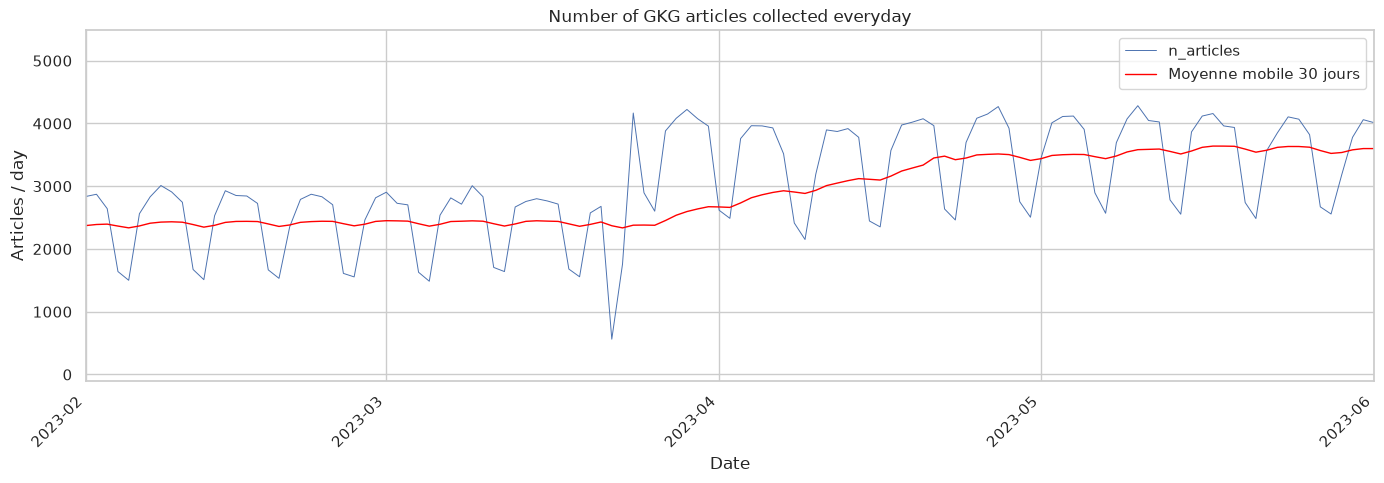

In [16]:
articles_per_day = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
    GROUP BY day
    ORDER BY day
""").df()

articles_per_day["day"] = pd.to_datetime(articles_per_day["day"])
articles_per_day = articles_per_day.set_index("day")

fig, ax = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1, color="red", label="Moyenne mobile 30 jours"
)

ax.set_title("Number of GKG articles collected everyday")
ax.set_ylabel("Articles / day")
ax.set_xlabel("Date")

ax.set_xlim(pd.to_datetime('2023-02-01'), pd.to_datetime('2023-06-01'))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

finding the extrema to analyze the data there : 

In [17]:
articles_per_day_min = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202303%'
    GROUP BY day
    ORDER BY n_articles ASC
    LIMIT 1    
""").df()

articles_per_day_max = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202303%'
    GROUP BY day
    ORDER BY n_articles DESC
    LIMIT 1    
""").df()

display(articles_per_day_min.style.format({"n_articles": "{:,}"}).hide(axis="index"))
display(articles_per_day_max.style.format({"n_articles": "{:,}"}).hide(axis="index"))

day,n_articles
2023-03-22 00:00:00,563


day,n_articles
2023-03-29 00:00:00,"4,223"


### 4.2.1 Most frequent themes

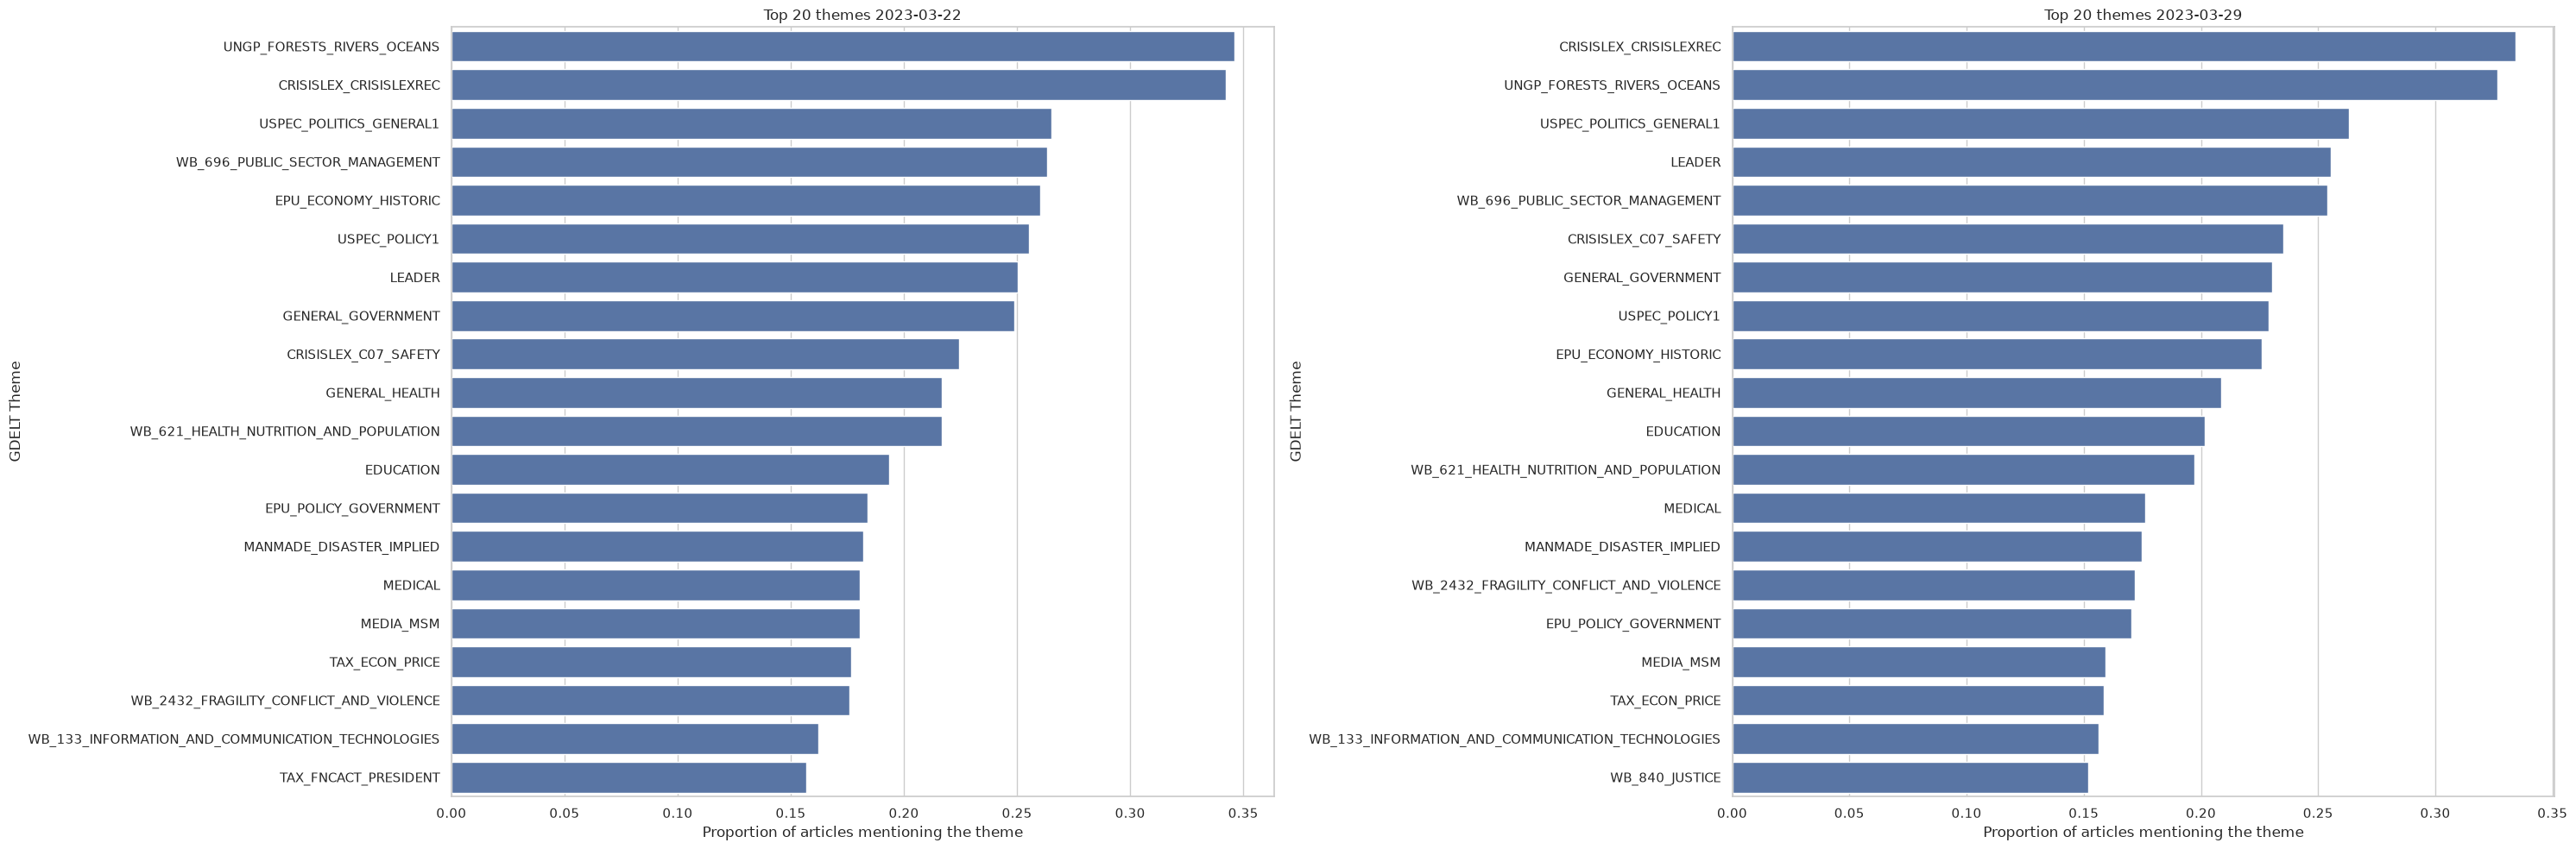

In [18]:
top_themes_2023_03_22 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE  STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'                                    
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'   
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_2023_03_29 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31'   
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31'   
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()


fig, axes = plt.subplots(1, 2, figsize=(30,10))

sns.barplot(data=top_themes_2023_03_22, x="proportion", y="theme", ax=axes[0])
axes[0].set_title('Top 20 themes 2023-03-22')
axes[0].set_xlabel('Proportion of articles mentioning the theme')
axes[0].set_ylabel('GDELT Theme')

sns.barplot(data=top_themes_2023_03_29, x="proportion", y="theme", ax=axes[1])
axes[1].set_title('Top 20 themes 2023-03-29')
axes[1].set_xlabel('Proportion of articles mentioning the theme')
axes[1].set_ylabel('GDELT Theme')

plt.tight_layout()
plt.show()

The most frequent themes are almost the same ones at the 3 extrema (19 shared themes out of 20), and the proportions are also pretty similar.

### 4.2.2 Theme variety per article

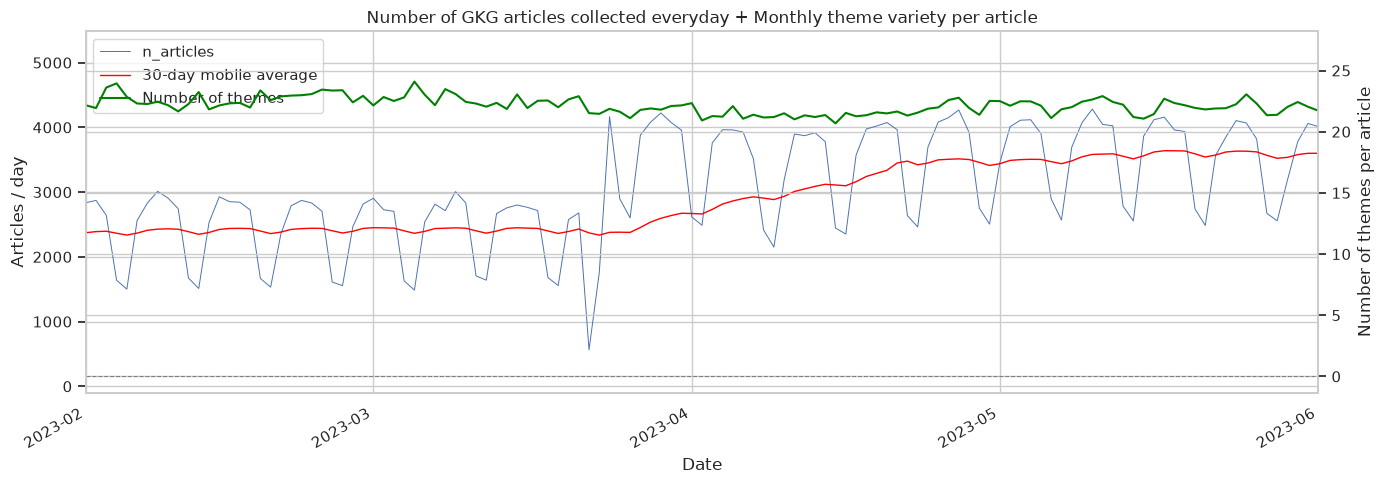

In [19]:
theme_variety_per_article_increase_2023 = con.execute("""
    WITH article_themes AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
    FROM (
        SELECT
            DATE,
            GKGRECORDID,
            UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_final_1pc
    )
    WHERE theme_raw IS NOT NULL
    AND theme_raw != ''
    GROUP BY day, GKGRECORDID
)

SELECT
    day,
    AVG(nb_themes) AS avg_themes_per_article
FROM article_themes
GROUP BY day
ORDER BY day;
""").df()


fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day mobile average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(theme_variety_per_article_increase_2023["day"], theme_variety_per_article_increase_2023["avg_themes_per_article"], color="green", label="Number of themes")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Number of themes per article")

ax1.set_title("Number of GKG articles collected everyday + Monthly theme variety per article")
ax1.set_xlim(pd.to_datetime('2023-02-01'), pd.to_datetime('2023-06-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The theme variety per article doesn't seem to be affected.

### 4.2.3 Tone

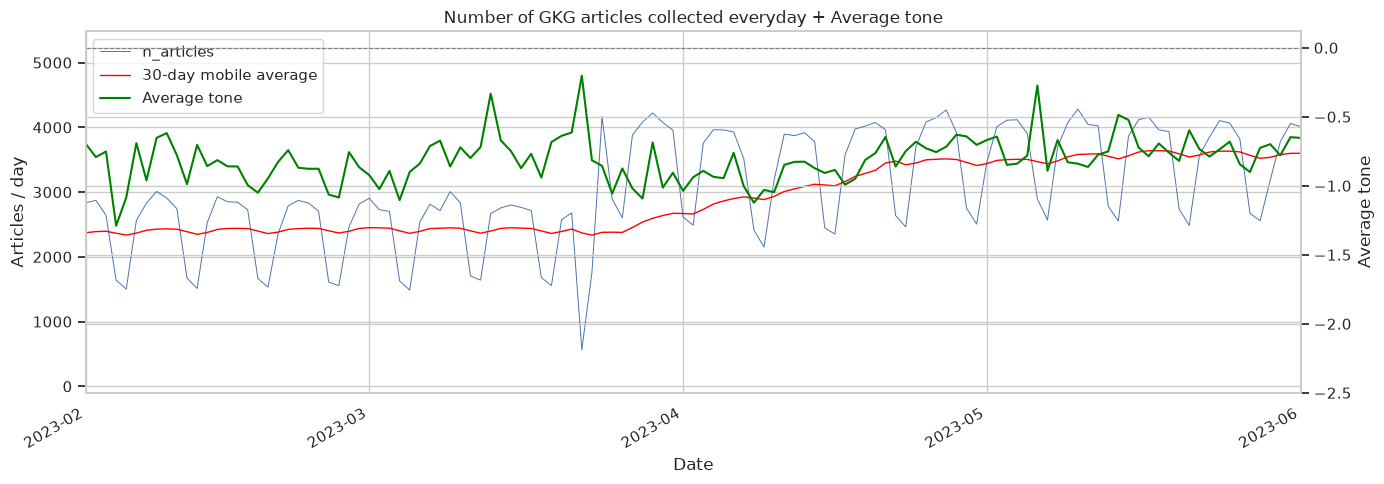

In [20]:
tone_increase_2023 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_final_1pc
    GROUP BY day
    ORDER BY day
""").df()

fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day mobile average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(tone_increase_2023["day"], tone_increase_2023["avg_tone"], color="green", label="Average tone")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Average tone")

ax1.set_title("Number of GKG articles collected everyday + Average tone")
ax1.set_xlim(pd.to_datetime('2023-02-01'), pd.to_datetime('2023-06-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The tone doesn't seem to be affected.

### 4.2.4 Main sources

In [71]:
n = 20 # top n sources 

top_n_sources_2023_03_22 = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22' 
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT ?
""",[n] ).df()

top_n_sources_2023_03_29 = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31'     
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT ?
""",[n] ).df()


display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2020-09-15</h4>
        {top_n_sources_2023_03_22.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-14</h4>
        {top_n_sources_2023_03_29.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Source_ID,Articles
businessdayonline.com,7823,130
iheart.com,82787,122
yahoo.com,81,78
zazoom.it,36148,57
news.yam.md,148367,25
finanznachrichten.de,3065,25
indiatimes.com,724,24
cfi.net.cn,61153,21
uol.com.br,7367,21
naslovi.net,31920,19


In [76]:
con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_2023_03_22 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22' 
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    OFFSET ?
""",[n] )

con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_2023_03_29 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31' 
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    OFFSET ?
""",[n] )

#### 4.2.4.1 Percentage of articles published by the top sources at each extrema
We want to see what percentage the top sources of 2023-03-22 (pre-increase top sources) accounts for on each extrema.

In [162]:
top_n_sources_2023_03_29_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2023_03_22
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2023_03_29
    ) AS i
    JOIN top_n_sources_2023_03_29 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2023_03_29_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,166
yahoo.com,151
msn.com,149
zazoom.it,106
news.yam.md,33
indiatimes.com,31
uol.com.br,31


In [166]:
nb_articles_per_day_2023_03_22 = con.execute("""
    WITH exploded AS (
        SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
            COUNT(*) AS nb_articles
        FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'    
        GROUP BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

nb_articles_per_day_2023_03_29 = con.execute("""
    WITH exploded AS (
        SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
            COUNT(*) AS nb_articles
        FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31'    
        GROUP BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [ ]:
values_nb_articles_total_2023_03_22 = [
    nb_articles_per_day_2023_03_22["avg_nb_articles"].iloc[0]
]

values_nb_articles_total_2023_03_29 = [
    nb_articles_per_day_2023_03_29["avg_nb_articles"].iloc[0]
]

res_pc_articles_by_top_n_sources_2023_03_22 = round(100 * (top_n_sources_2023_03_22["Articles"].sum() / values_nb_articles_total_2023_03_22[0]), 2)
res_pc_articles_by_top_n_sources_2023_03_29 = round(100 * (top_n_sources_2023_03_29_max["Articles"].sum() / values_nb_articles_total_2023_03_29[0]), 2)

print ("percentage artcles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2023_03_22, "%\n")
print ("percentage artcles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2023_03_29, "%\n")

percentage artcles published by the top n sources 2023-03-22 : 35.12 %

percentage artcles published by the top n sources 2023-03-22 : 16.33 %



#### 4.2.4.2 Percentage variation between the extrema - number of articles collected

In [72]:
# all sources

avg_nb_articles_2023_03_22_all_sources = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2023_03_29_all_sources = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [73]:
# top n sources 2023-03-22

avg_nb_articles_2023_03_22_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2023_03_22 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2023_03_29_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2023_03_22 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [77]:
# minus top n sources 2023-03-22

avg_nb_articles_2023_03_22_minus_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2023_03_22 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2023_03_29_minus_top_n_sources_1 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2023_03_22 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [74]:
# top n sources 2023-03-29

avg_nb_articles_2023_03_22_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2023_03_29 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2023_03_29_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN top_n_sources_2023_03_29 t
        ON g.SourceCommonName_ID = t.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [78]:
# minus top n sources 2023-03-29

avg_nb_articles_2023_03_22_minus_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2023_03_29 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

avg_nb_articles_2023_03_29_minus_top_n_sources_2 = con.execute("""
    WITH exploded AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(*) AS nb_articles
    FROM gkg_final_1pc g
    JOIN minus_top_n_sources_2023_03_29 m
        ON g.SourceCommonName_ID = m.Source_ID
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
    GROUP BY day
    ORDER BY day
    )
    SELECT
        AVG(nb_articles) AS avg_nb_articles
    FROM exploded;
""").df()

In [80]:
values_all_sources = [
    avg_nb_articles_2023_03_22_all_sources["avg_nb_articles"].iloc[0],
    avg_nb_articles_2023_03_29_all_sources["avg_nb_articles"].iloc[0]
]

values_top_n_sources_1 = [
    avg_nb_articles_2023_03_22_top_n_sources_1["avg_nb_articles"].iloc[0],
    avg_nb_articles_2023_03_29_top_n_sources_1["avg_nb_articles"].iloc[0]
]

values_minus_top_n_sources_1 = [
    avg_nb_articles_2023_03_22_minus_top_n_sources_1["avg_nb_articles"].iloc[0],
    avg_nb_articles_2023_03_29_minus_top_n_sources_1["avg_nb_articles"].iloc[0]
]

values_top_n_sources_2 = [
    avg_nb_articles_2023_03_22_top_n_sources_2["avg_nb_articles"].iloc[0],
    avg_nb_articles_2023_03_29_top_n_sources_2["avg_nb_articles"].iloc[0]
]

values_minus_top_n_sources_2 = [
    avg_nb_articles_2023_03_22_minus_top_n_sources_2["avg_nb_articles"].iloc[0],
    avg_nb_articles_2023_03_29_minus_top_n_sources_2["avg_nb_articles"].iloc[0]
]


res_values_all_sources = round(100 * (values_all_sources[1] / values_all_sources[0] - 1), 2)

res_values_top_n_sources_1 = round(100 * (values_top_n_sources_1[1] / values_top_n_sources_1[0] - 1), 2)

res_values_minus_top_n_sources_1 = round(100 * (values_minus_top_n_sources_1[1] / values_minus_top_n_sources_1[0] - 1), 2)

res_values_top_n_sources_2 = round(100 * (values_top_n_sources_2[1] / values_top_n_sources_2[0] - 1), 2)

res_values_minus_top_n_sources_2 = round(100 * (values_minus_top_n_sources_2[1] / values_minus_top_n_sources_2[0] - 1), 2)


print ("percentage variation all sources :", res_values_all_sources, "%\n")

print ("percentage variation top n sources 2023-03-22 :", res_values_top_n_sources_1, "%\n")

print ("percentage variation minus top n sources 2023-03-22 :", res_values_minus_top_n_sources_1, "%\n")

print ("percentage variation top n sources 2023-03-29 :", res_values_top_n_sources_2, "%\n")

print ("percentage variation minus top n sources 2023-03-29 :", res_values_minus_top_n_sources_2, "%\n")

percentage variation all sources : 72.58 %

percentage variation top n sources 2023-03-22 : -3.02 %

percentage variation minus top n sources 2023-03-22 : -0.43 %

percentage variation top n sources 2023-03-29 : 152.52 %

percentage variation minus top n sources 2023-03-29 : 116.85 %



#### 4.2.4.3 Percentage variation between the extrema - theme variety

In [97]:
# all sources

avg_theme_variety_2023_03_22_all_sources = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2023_03_29_all_sources = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [100]:
# top n sources 2023-03-22

avg_theme_variety_2023_03_22_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2023_03_22 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2023_03_29_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2023_03_22 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [99]:
# minus top n sources 2023-03-22

avg_theme_variety_2023_03_22_minus_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2023_03_22 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2023_03_29_minus_top_n_sources_1 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2023_03_22 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [101]:
# top n sources 2023-03-29

avg_theme_variety_2023_03_22_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2023_03_29 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2023_03_29_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN top_n_sources_2023_03_29 t
                    ON g.SourceCommonName_ID = t.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [102]:
# minus top n sources 2023-03-29

avg_theme_variety_2023_03_22_minus_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2023_03_29 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-16'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

avg_theme_variety_2023_03_29_minus_top_n_sources_2 = con.execute("""
    WITH article_themes AS (
        SELECT
            day,
            AVG(nb_themes) AS avg_nb_themes_per_article_per_day
        FROM (
            SELECT
                DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
                COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
            FROM (
                SELECT
                    DATE,
                    GKGRECORDID,
                    UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
                FROM gkg_final_1pc g
                JOIN minus_top_n_sources_2023_03_29 m
                    ON g.SourceCommonName_ID = m.Source_ID
            )
            WHERE theme_raw IS NOT NULL
            AND theme_raw != ''
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-04'
            GROUP BY day, GKGRECORDID
        )
        GROUP BY day
    )
    SELECT
        AVG(avg_nb_themes_per_article_per_day) AS avg_nb_themes_per_article
    FROM article_themes
""").df()

In [103]:
values_all_sources = [
    avg_theme_variety_2023_03_22_all_sources["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2023_03_29_all_sources["avg_nb_themes_per_article"].iloc[0]
]

values_top_n_sources_1 = [
    avg_theme_variety_2023_03_22_top_n_sources_1["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2023_03_29_top_n_sources_1["avg_nb_themes_per_article"].iloc[0]
]

values_minus_top_n_sources_1 = [
    avg_theme_variety_2023_03_22_minus_top_n_sources_1["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2023_03_29_minus_top_n_sources_1["avg_nb_themes_per_article"].iloc[0]
]

values_top_n_sources_2 = [
    avg_theme_variety_2023_03_22_top_n_sources_2["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2023_03_29_top_n_sources_2["avg_nb_themes_per_article"].iloc[0]
]

values_minus_top_n_sources_2 = [
    avg_theme_variety_2023_03_22_minus_top_n_sources_2["avg_nb_themes_per_article"].iloc[0],
    avg_theme_variety_2023_03_29_minus_top_n_sources_2["avg_nb_themes_per_article"].iloc[0]
]


res_values_all_sources = round(100 * (values_all_sources[1] / values_all_sources[0] - 1), 2)

res_values_top_n_sources_1 = round(100 * (values_top_n_sources_1[1] / values_top_n_sources_1[0] - 1), 2)

res_values_minus_top_n_sources_1 = round(100 * (values_minus_top_n_sources_1[1] / values_minus_top_n_sources_1[0] - 1), 2)

res_values_top_n_sources_2 = round(100 * (values_top_n_sources_2[1] / values_top_n_sources_2[0] - 1), 2)

res_values_minus_top_n_sources_2 = round(100 * (values_minus_top_n_sources_2[1] / values_minus_top_n_sources_2[0] - 1), 2)


print ("percentage variation all sources :", res_values_all_sources, "%\n")

print ("percentage variation top n sources 2023-03-22 :", res_values_top_n_sources_1, "%\n")

print ("percentage variation minus top n sources 2023-03-22 :", res_values_minus_top_n_sources_1, "%\n")

print ("percentage variation top n sources 2023-03-29 :", res_values_top_n_sources_2, "%\n")

print ("percentage variation minus top n sources 2023-03-29 :", res_values_minus_top_n_sources_2, "%\n")

percentage variation all sources : -2.73 %

percentage variation top n sources 2023-03-22 : 9.5 %

percentage variation minus top n sources 2023-03-22 : -4.0 %

percentage variation top n sources 2023-03-29 : 13.27 %

percentage variation minus top n sources 2023-03-29 : -1.41 %

